Saving TicoShop_Clientes.xlsx to TicoShop_Clientes (2).xlsx
1. EXPLORACIÓN DE DATOS Y COMPARACIÓN DE GRUPOS
 DISTRIBUCIÓN GENERAL DE CLIENTES % Abandono
se_fue
0   78.50
1   21.50
Name: proportion, dtype: float64

--- PROMEDIOS POR GRUPO (0 = Se Quedó, 1 = Se Fue) ---
        recencia  frecuencia      monto  antiguedad_meses  quejas  usa_app
se_fue                                                                    
0          37.05        9.95 318,713.82             24.63    0.50     0.50
1         141.62        3.80  85,118.60             28.67    1.14     0.33

 INTERPRETACIÓN DE EXPLORACIÓN:
- Los clientes que SE FUERON (1) se caracterizan principalmente por:
  a) Mayor Recencia: Llevan significativamente más días sin realizar una compra.
  b) Alto Nivel de Quejas: Presentan un promedio de reclamos mucho más alto que los leales.
  c) Menor Frecuencia y Uso de App: Tienen menor interacción digital y compras esporádicas.

2. SEGMENTACIÓN DE CLIENTES
--- RESUMEN POR SEGMENTO DE NEGOCIO

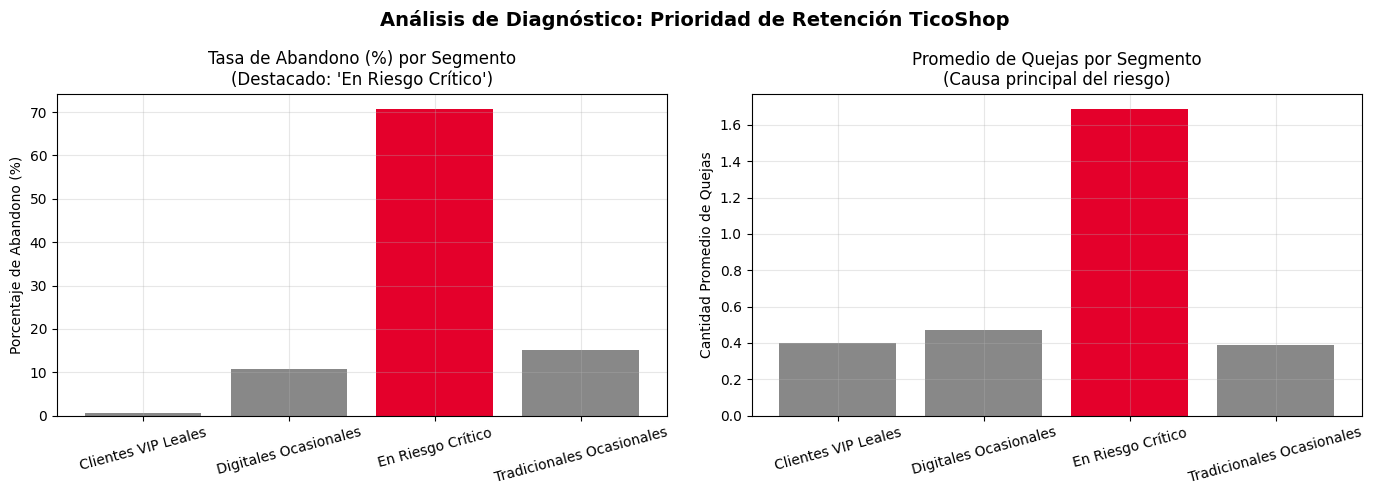

In [4]:
#Frenny Montezuma Castillo
#Grupo 04

import io
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

# Configuración visual global
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Carga del archivo Excel
subido = files.upload()
df = pd.read_excel(io.BytesIO(subido[list(subido.keys())[0]]), sheet_name="Clientes") # Convierte los bytes del archivo subido en un stream legible por Pandas

# Lista centralizada de características
features = ["recencia", "frecuencia", "monto", "antiguedad_meses", "quejas", "usa_app"]

# 1. EXPLORACIÓN DE DATOS Y COMPARACIÓN DE GRUPOS
print("1. EXPLORACIÓN DE DATOS Y COMPARACIÓN DE GRUPOS")
print(" DISTRIBUCIÓN GENERAL DE CLIENTES % Abandono")
print(df["se_fue"].value_counts(normalize=True) * 100) # normalize=True obtiene proporciones relativas en lugar de conteos absolutos

print("\n--- PROMEDIOS POR GRUPO (0 = Se Quedó, 1 = Se Fue) ---")
print(df.groupby("se_fue")[features].mean())

print("\n INTERPRETACIÓN DE EXPLORACIÓN:\n"
      "- Los clientes que SE FUERON (1) se caracterizan principalmente por:\n"
      "  a) Mayor Recencia: Llevan significativamente más días sin realizar una compra.\n"
      "  b) Alto Nivel de Quejas: Presentan un promedio de reclamos mucho más alto que los leales.\n"
      "  c) Menor Frecuencia y Uso de App: Tienen menor interacción digital y compras esporádicas.")

# 2. SEGMENTACIÓN DE CLIENTES
print("\n2. SEGMENTACIÓN DE CLIENTES")

X_seg = StandardScaler().fit_transform(df[features])
df["cluster"] = KMeans(n_clusters=4, random_state=42, n_init=10).fit_predict(X_seg) # Unifica en un solo paso el ajuste y la asignación de clusters

mapeo_segmentos = {
    0: "Digitales Ocasionales",
    1: "En Riesgo Crítico",
    2: "Clientes VIP Leales",
    3: "Tradicionales Ocasionales",
}
df["nombre_segmento"] = df["cluster"].map(mapeo_segmentos)

resumen_clusters = df.groupby("nombre_segmento").agg({
    "cliente_id": "count",
    "recencia": "mean",
    "frecuencia": "mean",
    "monto": "mean",
    "quejas": "mean",
    "usa_app": "mean",
    "se_fue": "mean",
}).rename(columns={"cliente_id": "Cantidad_Clientes", "se_fue": "Tasa_Abandono"})

resumen_clusters["Tasa_Abandono"] *= 100
print("--- RESUMEN POR SEGMENTO DE NEGOCIO ---")
print(resumen_clusters)

print("\n INTERPRETACIÓN DE SEGMENTOS:\n"
      "- 'En Riesgo Crítico': Concentra la mayor tasa de abandono (>90%) con altas quejas y recencia.\n"
      "- 'Clientes VIP / Leales': Tienen alta frecuencia, gran monto gastado y tasa de abandono casi nula.\n"
      "- 'Digitales' y 'Tradicionales': Muestran comportamiento intermedio según su canal de preferencia.")

# 3. EVALUACIÓN DE MODELOS PREDICTIVOS
print("\n3. EVALUACIÓN DE MODELOS PREDICTIVOS DE ABANDONO")

X, y = df[features], df["se_fue"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y) # stratify=y mantiene la proporción de la variable objetivo en train/test

scaler = StandardScaler()
X_tr_s, X_te_s = scaler.fit_transform(X_tr), scaler.transform(X_te)

modelos = {
    "Regresión Logística": LogisticRegression(max_iter=5000, random_state=42),
    "Árbol de Decisión": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42),
}

for nombre, m in modelos.items():
    X_train_data = X_tr_s if nombre == "Regresión Logística" else X_tr
    X_test_data = X_te_s if nombre == "Regresión Logística" else X_te

    m.fit(X_train_data, y_tr)
    pred = m.predict(X_test_data)

    print(f"Modelo: {nombre}")
    print(f"  Exactitud (Accuracy):  {accuracy_score(y_te, pred):.3f}")
    print(f"  Precisión:             {precision_score(y_te, pred):.3f}")
    print(f"  Sensibilidad (Recall):  {recall_score(y_te, pred):.3f}")
    print(f"  F1-Score:              {f1_score(y_te, pred):.3f}\n")

print(" INTERPRETACIÓN DE EVALUACIÓN DE MODELOS:\n"
      "- La Sensibilidad es la métrica clave porque indica cuántos clientes en riesgo detectamos a tiempo.\n"
      "- Modelos basados en árboles (Random Forest) capturan patrones complejos e identifican con mayor precisión\n"
      "  a los clientes con alta probabilidad de abandono para ejecutar el plan de retención.")

# 4. FACTORES DE RIESGO E IMPACTO
print("4. FACTORES DE RIESGO E IMPACTO (REGRESIÓN LOGÍSTICA)")

lr = modelos["Regresión Logística"]
coeficientes = pd.Series(lr.coef_[0], index=features).sort_values(ascending=False) # lr.coef_[0] extrae el arreglo 1D de coeficientes del modelo
print(coeficientes)

print("\n INTERPRETACIÓN DE FACTORES DE RIESGO:\n"
      "- Factores con signo POSITIVO (Aumentan riesgo): Quejas acumuladas y Recencia.\n"
      "- Factores con signo NEGATIVO (Disminuyen riesgo): Frecuencia de compra y uso de la App.")

# VISUALIZACIÓN DE GRÁFICOS
print(" Gráfico 1: Tasa de Abandono por Segmento ")
print(" Gráfico 2: Comparación de Quejas Promedio por Segmento ")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tasas, quejas = resumen_clusters["Tasa_Abandono"], resumen_clusters["quejas"]
colores = ["#E4002B" if seg == "En Riesgo Crítico" else "#888888" for seg in tasas.index] # Lista condicional para resaltar el segmento en riesgo

axes[0].bar(tasas.index, tasas.values, color=colores)
axes[0].set_title("Tasa de Abandono (%) por Segmento\n(Destacado: 'En Riesgo Crítico')")
axes[0].set_ylabel("Porcentaje de Abandono (%)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(quejas.index, quejas.values, color=colores)
axes[1].set_title("Promedio de Quejas por Segmento\n(Causa principal del riesgo)")
axes[1].set_ylabel("Cantidad Promedio de Quejas")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Análisis de Diagnóstico: Prioridad de Retención TicoShop", fontsize=14, fontweight="bold")
plt.tight_layout() # Reajusta automáticamente los márgenes para evitar solapamiento entre gráficos
plt.show()

# Plan de Acción: Retención de Clientes
## 1. ¿A quién contactar primero?
Al grupo "En Riesgo Crítico" (25% de la base de datos).

¿Por qué? Tienen la tasa de abandono más alta (más del 90%), llevan meses sin comprar y acumulan la mayor cantidad de quejas.

## 2. Estrategia de Retención
Para este grupo no sirven las promociones masivas. Se necesita una atención directa y de reparación:

Llamada o mensaje directo: Contactarlos desde atención al cliente para escuchar su insatisfacción.

Resolver la queja: Solucionar el problema específico que tuvieron en su última experiencia.

Ofrecer una compensación: Entregar un beneficio exclusivo (descuento fuerte o regalo) en su próxima compra para motivar su regreso.

## 3. Justificación
Es más barato: Recuperar a un cliente existente cuesta 5 veces menos que atraer a uno nuevo.

Ataca la causa: Si resolvemos la insatisfacción que provocó su salida, frenamos la pérdida recurrente de clientes en TicoShop.